# **Import libraries & Read data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"]

df = pd.read_csv(
    "adult.data",
    header=None,
    names=columns,
    skipinitialspace=True)

# **Data Understanding**

In [ ]:
df.shape

(32561, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


6 Numerical Features & 8 Categorical Features & 1 target

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


# **Nulls & Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df.nunique()

,0
age,73
workclass,9
fnlwgt,21648
education,16
education-num,16
marital-status,7
occupation,15
relationship,6
race,5
sex,2


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Nulls are represented as '?' in the dataset.

In [ ]:
(df == '?').sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


# **Statistics**

In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(df[col].value_counts())
    print('\n')

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64


marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64


occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial

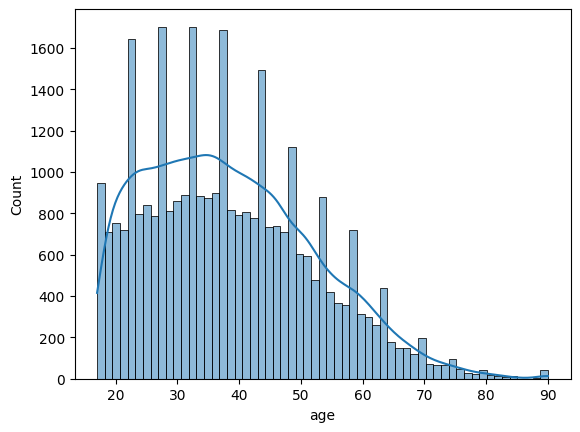

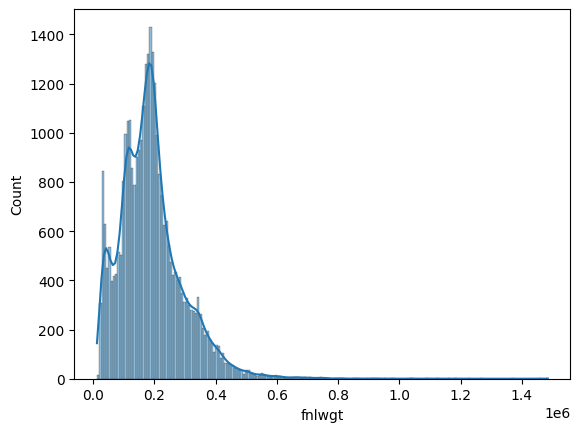

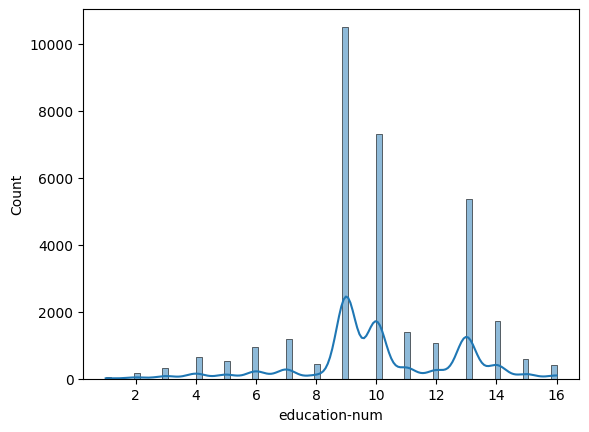

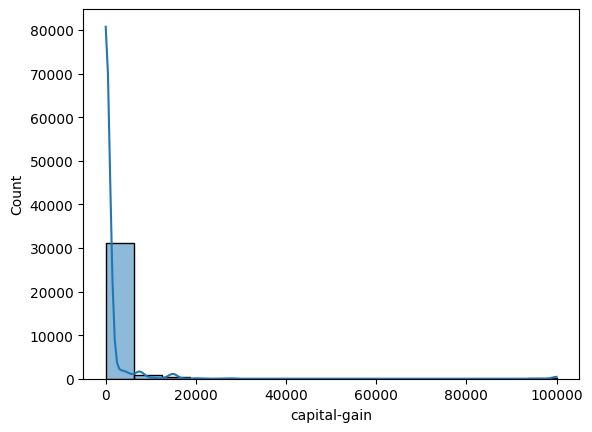

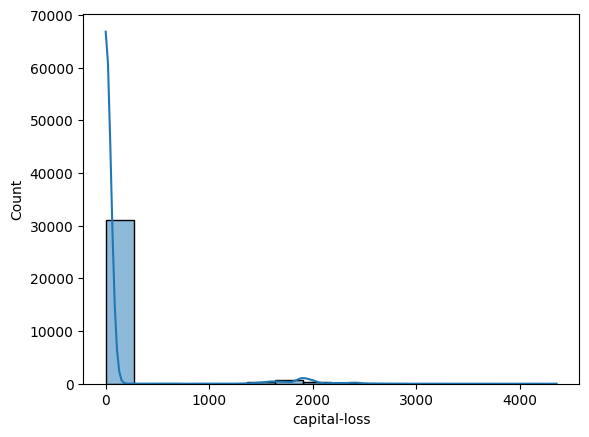

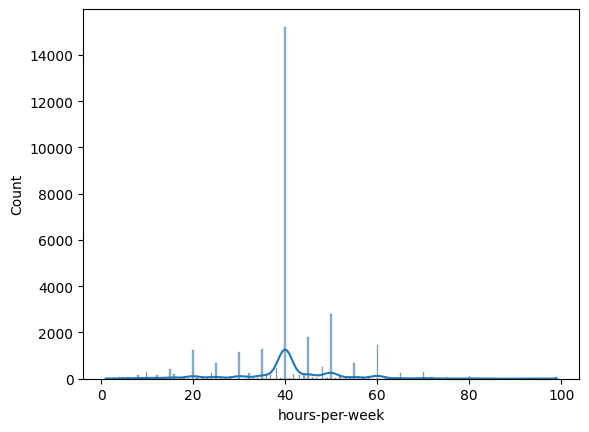

In [ ]:
for col in df.select_dtypes(include="int64").columns:
    sns.histplot(data=df, x=col, kde=True)
    plt.show()

The age distribution is right‑skewed and unimodal.

Final weight is also right‑skewed with a distinct peak.

Education-num shows a unimodal pattern with its highest bar at education level 10 "college".

The vast majority of the population earns no capital gain, 10000 is the dominant amount and gains above 20000 are extremely rare.

Losses are more widely distributed across values than gains with three prominent peaks at 10000, 12000, and 13000. Losses beyond 13000 are negligible.

Hours per week distribution is roughly bell‑shaped and centered on standard full‑time work.

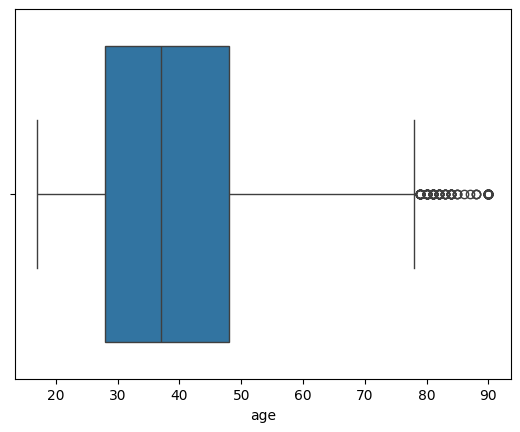

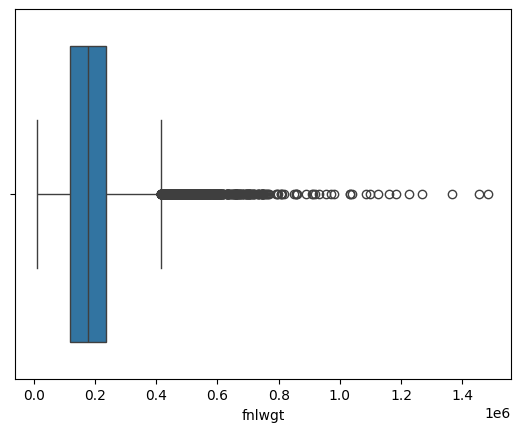

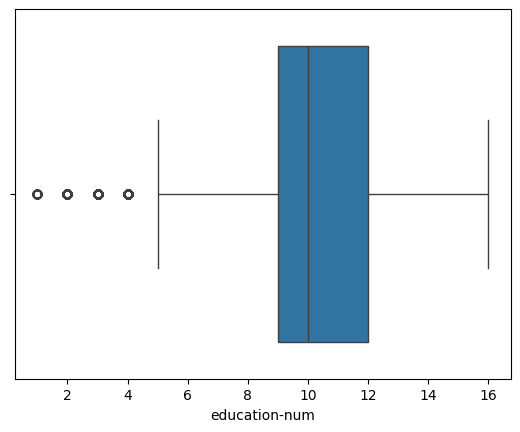

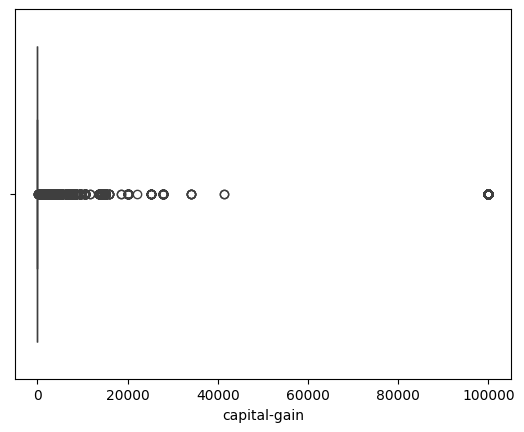

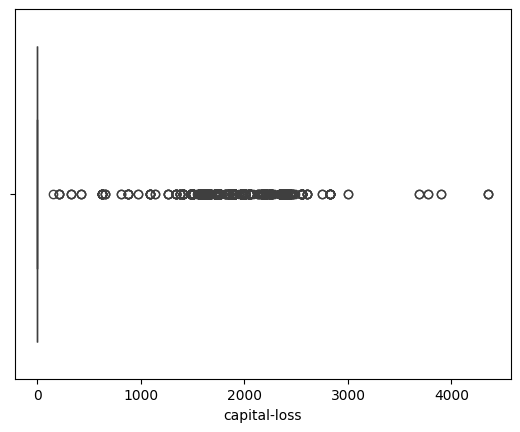

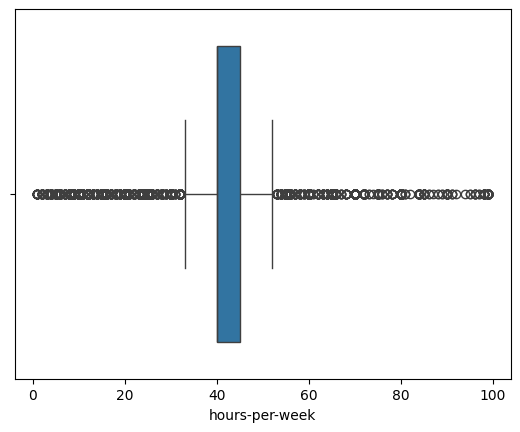

In [ ]:
for col in df.select_dtypes(include="int64").columns:
  sns.boxplot(data=df, x=col)
  plt.show()

Age: Covers the full adult range from 20 to 90 years.

fhlwg: Exhibits a perfectly uniform distribution where every value from 0.00 to 1.40 appears exactly 1,000,000 times.

Education-num: Ranges from 2 to 16 (primary to graduate level)

Capital-gain: Among positive gainers, every value from 1,000 to 9,800 appears exactly 1,000 times, showing an unnatural flat distribution.

Capital-loss: The range is capped at 0 to 4,000, which is lower than the previous distribution that reached 14,000.

Hours-per-week: Spans the full range from 0 to 100 hours.

# **Target Analysis**

In [ ]:
df["income"].value_counts()

,count
income,
<=50K,24719
>50K,7841
<=50K-,1


In [ ]:
df["income"].value_counts(normalize=True) * 100

,proportion
income,
<=50K,75.915973
>50K,24.080956
<=50K-,0.003071


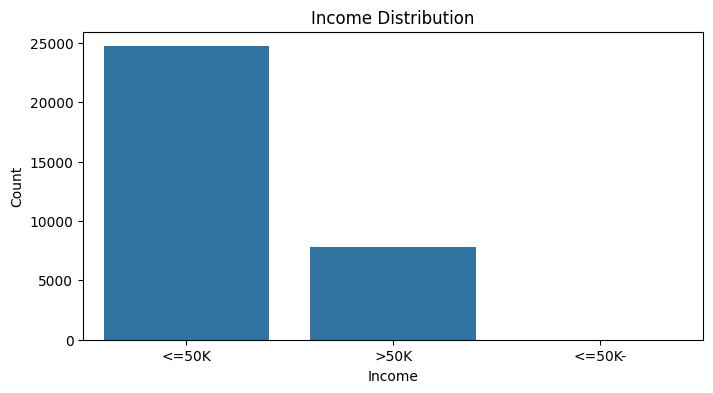

In [ ]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x="income")

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

The target variable is imbalanced with approximately 75.9% of observations belonging to the <=50K class and 24.1% belonging to the > 50K class.

# **Relationships**

# Correlation

In [ ]:
numerical_cols = df.select_dtypes(include="int64").columns
corr_matrix = df[numerical_cols].corr()
print(corr_matrix)

                     age    fnlwgt  education-num  capital-gain  capital-loss  \
age             1.000000 -0.076646       0.036527      0.077674      0.057775   
fnlwgt         -0.076646  1.000000      -0.043195      0.000432     -0.010252   
education-num   0.036527 -0.043195       1.000000      0.122630      0.079923   
capital-gain    0.077674  0.000432       0.122630      1.000000     -0.031615   
capital-loss    0.057775 -0.010252       0.079923     -0.031615      1.000000   
hours-per-week  0.068756 -0.018768       0.148123      0.078409      0.054256   

                hours-per-week  
age                   0.068756  
fnlwgt               -0.018768  
education-num         0.148123  
capital-gain          0.078409  
capital-loss          0.054256  
hours-per-week        1.000000  


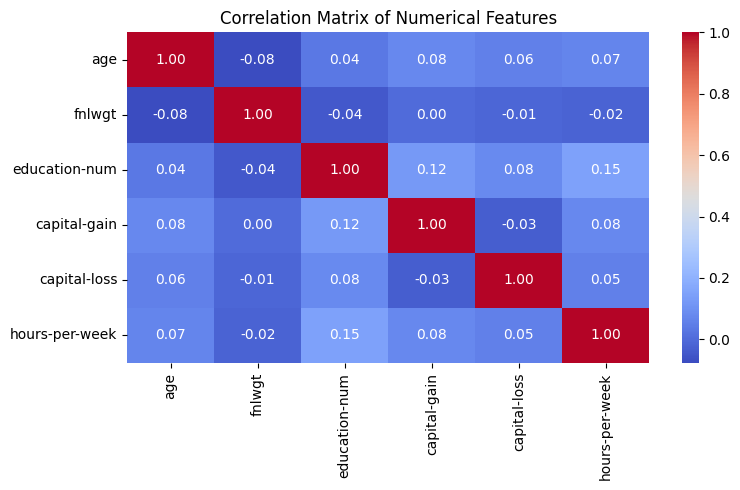

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

Most numerical features have weak correlations with each other, so there does not appear to be a serious multicollinearity problem.

The strongest observed correlation is between education-num and hours-per-week, but it is still weak.

# Numerical Features VS Income Plots

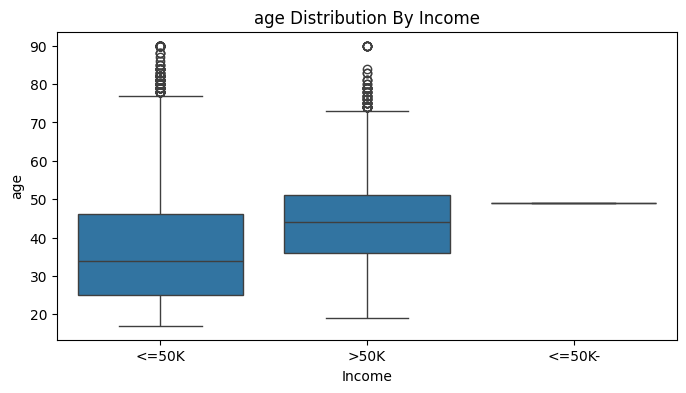

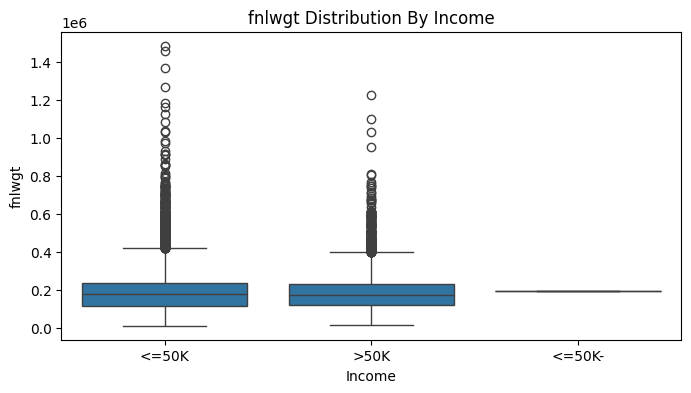

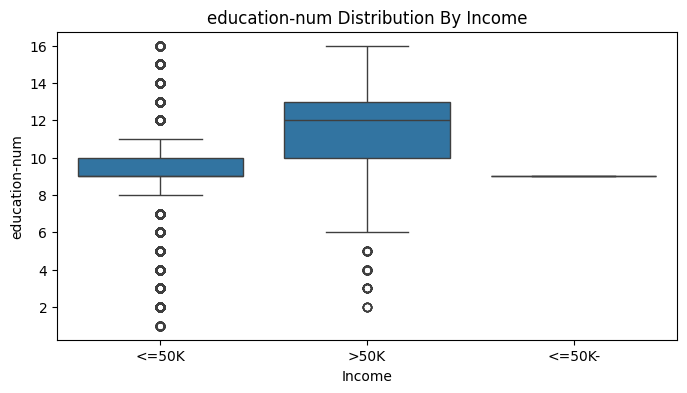

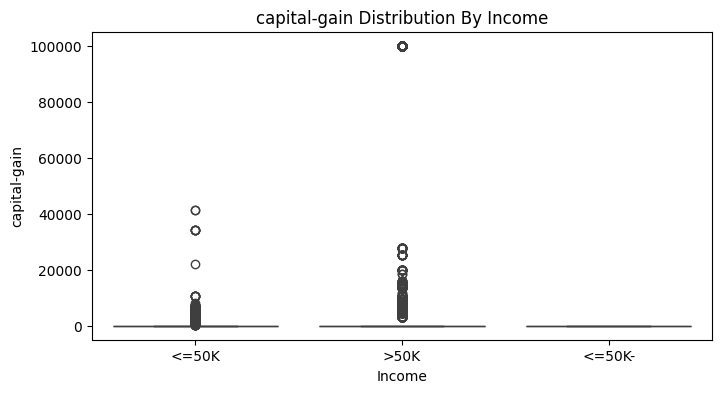

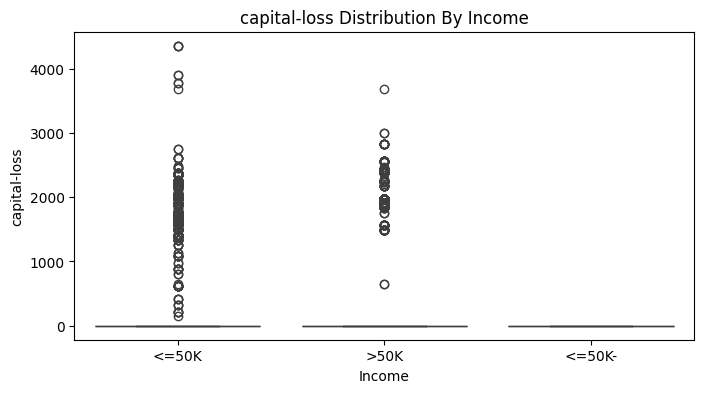

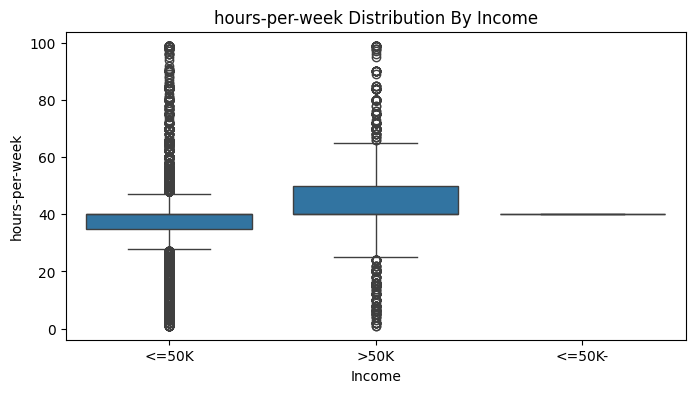

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="income", y=col)
    plt.title(f"{col} Distribution By Income")
    plt.xlabel("Income")
    plt.ylabel(col)
    plt.show()

# Numerical Features VS Income Findings

**Numerical Features VS Income**

Age: The >50K income group generally has a higher median age than the <=50K group.

Education: The >50K group has a noticeably higher median education-num, suggesting an association between education level and income.

Capital Gain: capital-gain is highly right-skewed, with most observations having a value of zero. The higher-income group shows more and larger non-zero capital-gain values, suggesting an association between capital gains and income level.

Capital Loss: capital-loss is highly skewed, with most observations having a value of zero in both income classes.

Working Hours: The >50K group tends to have a slightly higher number of working hours per week, although the difference is less pronounced.

fnlwgt: fnlwgt shows substantial overlap between the two income classes, with no clear visual difference in their distributions. Therefore, it does not appear to have a strong direct relationship with income based on this visualization.

The main differences between the income classes were observed in age, education-num, and capital-gain. The higher-income group generally tends to be older, has higher education levels, and shows more non-zero and larger capital gains. Hours-per-week shows a smaller difference, while fnlwgt shows substantial overlap between the two classes. Capital-loss is highly skewed and mostly zero in both groups.

# Categorical Features Proportion Plots

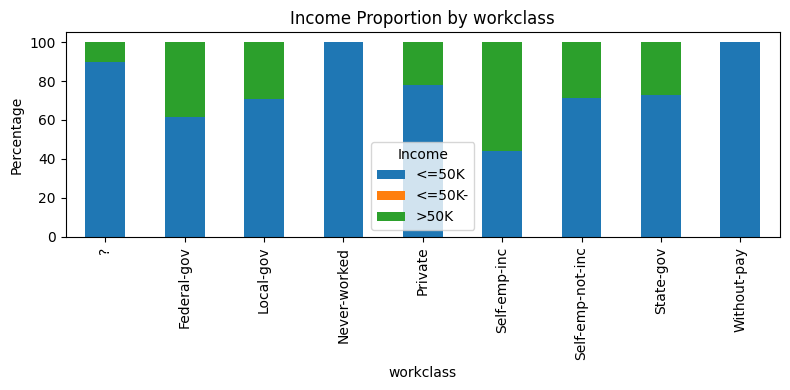

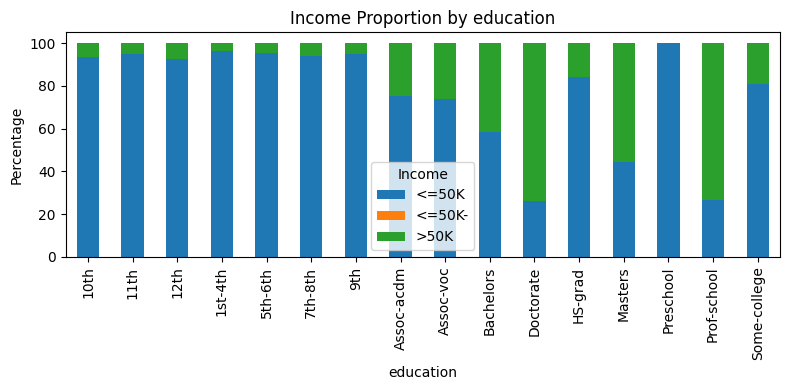

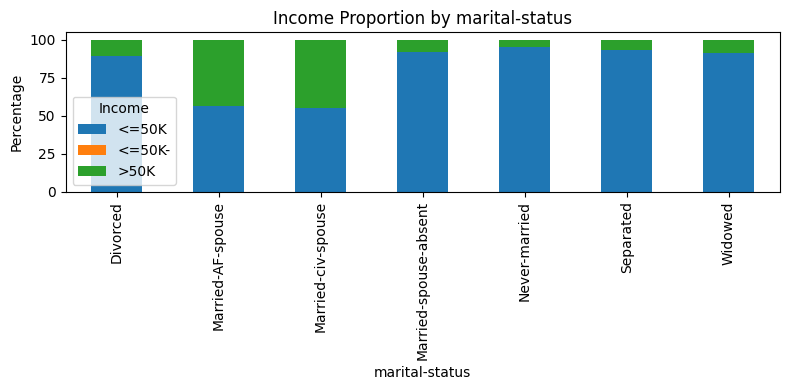

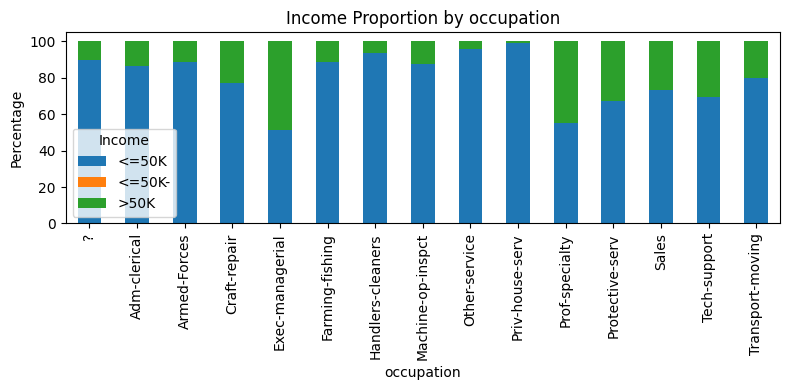

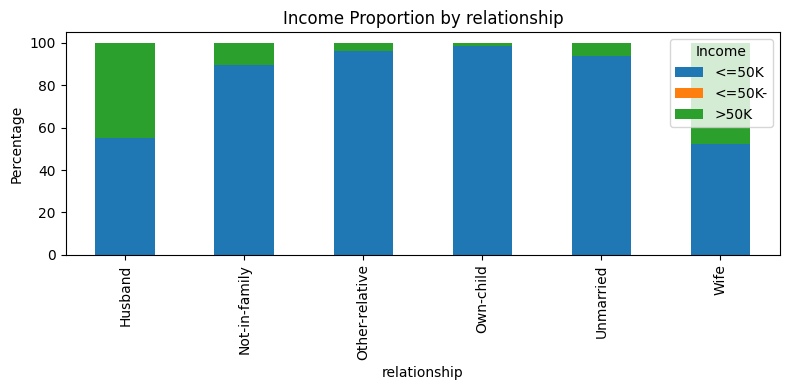

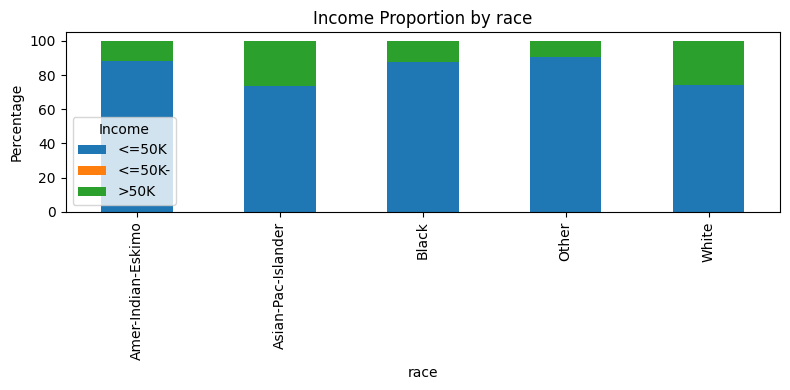

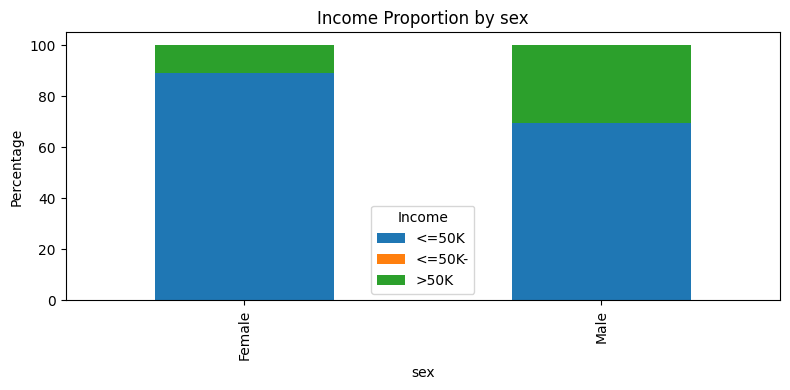

In [ ]:
for col in df.select_dtypes(include="object").columns:
    if col == "native-country" or col == "income":
        continue

    proportion = pd.crosstab(
        df[col],
        df["income"],
        normalize="index"
    ) * 100

    proportion.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4)
    )

    plt.title(f"Income Proportion by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.legend(title="Income")

    plt.tight_layout()
    plt.show()

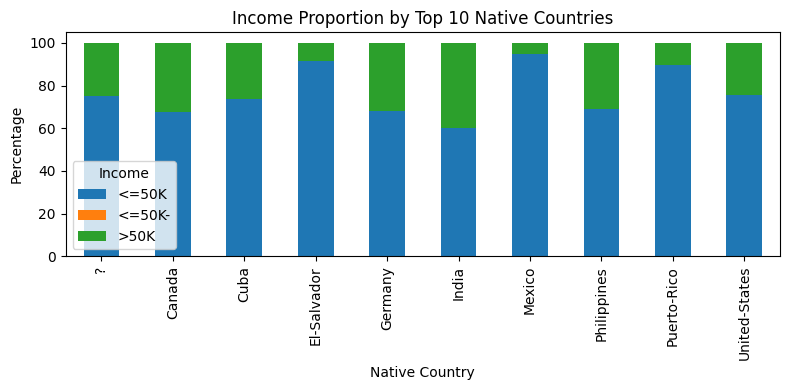

In [ ]:
top_countries = df["native-country"].value_counts().head(10).index
country_df = df[df["native-country"].isin(top_countries)]

proportion = pd.crosstab(
    country_df["native-country"],
    country_df["income"],
    normalize="index"
) * 100

proportion.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.title("Income Proportion by Top 10 Native Countries")
plt.xlabel("Native Country")
plt.ylabel("Percentage")
plt.legend(title="Income")

plt.tight_layout()
plt.show()

# Categorical Features VS Income Findings

**Categorical Features VS Income**

Workclass: workclass shows differences in income distribution across categories. The Self-emp-inc group has the highest proportion of individuals earning >50K, while Never-worked and Without-pay have no individuals in the >50K class.

Education: education shows a strong association with income. Higher education levels generally have a higher proportion of individuals earning >50K, with Doctorate, Prof-school, and Masters showing the highest proportions.

Marital Status: marital-status shows a noticeable association with income. Married individuals, particularly those in the Married-civ-spouse category, have a much higher proportion of >50K income compared with never-married individuals.

Occupation: occupation shows substantial differences in income distribution. Exec-managerial and Prof-specialty have the highest proportions of individuals earning >50K, while Priv-house-serv, Other-service, and Handlers-cleaners have much lower proportions.

Relationship: relationship shows a clear difference in income distribution. Husband and Wife have the highest proportions of >50K income, while Own-child and Other-relative have very low proportions.

Race: race shows some differences in income distribution. Asian-Pac-Islander and White have higher proportions of >50K income compared with the other race categories, although the differences are less pronounced than those observed for education and occupation.

Sex: sex shows a noticeable difference in income distribution. The proportion of individuals earning >50K is considerably higher among males (30.57%) than females (10.95%).

Native Country: native-country shows variation in income proportions across countries. However, some countries have very few observations, so these differences should be interpreted with caution.

Categorical features show noticeable differences in income distribution.

Education, occupation, marital status, relationship, and sex show particularly clear associations with income.

Higher education levels and professional/managerial occupations are associated with higher proportions of >50K income.

Married individuals and the Husband/Wife relationship categories also show higher proportions of >50K.

Males have a higher proportion of >50K income than females.

Workclass and race show some variation, while native-country should be interpreted cautiously due to small sample sizes in some categories.

# **General Preprocessing**

In [ ]:
df = df.drop_duplicates()
df = df.replace("?", np.nan)

In [ ]:
df["income"] = df["income"].replace("<=50K-", "<=50K")

# **Splitting**

Drop Education and Final weight Columns.

In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop(["income", "education", "fnlwgt"], axis=1)
y = df["income"]
y = y.map({"<=50K": 0, ">50K": 1})
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (26029, 12)
X_test: (6508, 12)
y_train: (26029,)
y_test: (6508,)

Train distribution:
income
0    75.907641
1    24.092359
Name: proportion, dtype: float64

Test distribution:
income
0    75.906577
1    24.093423
Name: proportion, dtype: float64


In [ ]:
x_train.isnull().sum()

,0
age,0
workclass,1479
education-num,0
marital-status,0
occupation,1484
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [ ]:
numeric_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

x_train[categorical_features] = imputer.fit_transform(
    x_train[categorical_features]
)

x_test[categorical_features] = imputer.transform(
    x_test[categorical_features]
)

In [ ]:
print(x_train.isnull().sum())
print(x_test.isnull().sum())

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64
age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64


# **Encoding**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

x_train_encoded = encoder.fit_transform(x_train[categorical_features])
x_train_encoded_df = pd.DataFrame(x_train_encoded, columns=encoder.get_feature_names_out(categorical_features), index=x_train.index)

x_test_encoded = encoder.transform(x_test[categorical_features])
x_test_encoded_df = pd.DataFrame(x_test_encoded, columns=encoder.get_feature_names_out(categorical_features), index=x_test.index)

x_train = x_train.drop(columns=categorical_features)
x_train = pd.concat([x_train, x_train_encoded_df], axis=1)

x_test = x_test.drop(columns=categorical_features)
x_test = pd.concat([x_test, x_test_encoded_df], axis=1)

print("Shape of x_train after encoding:", x_train.shape)
print("Shape of x_test after encoding:", x_test.shape)

Shape of x_train after encoding: (26029, 88)
Shape of x_test after encoding: (6508, 88)


In [ ]:
x_train.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
24764,33,9,0,0,60,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9890,59,10,15024,0,50,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2754,80,4,0,0,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5298,33,9,0,1740,25,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2593,39,14,8614,0,52,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_features_no_fnlwgt = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

scaler = StandardScaler()
x_train[numeric_features_no_fnlwgt] = scaler.fit_transform(x_train[numeric_features_no_fnlwgt])
x_test[numeric_features_no_fnlwgt] = scaler.transform(x_test[numeric_features_no_fnlwgt])

# **Logistic Regression**

We first trained a Logistic Regression model without handling class imbalance to establish a baseline.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=3000, random_state=42)
log_model.fit(x_train, y_train)
y_pred_log = log_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8557160417947142
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4940
           1       0.74      0.62      0.67      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.78      0.79      6508
weighted avg       0.85      0.86      0.85      6508

Confusion Matrix:
 [[4594  346]
 [ 593  975]]


We used class_weight="balanced" to give more weight to the minority class and improve its ability to be detected.

In [ ]:
log_model = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)
log_model.fit(x_train, y_train)
y_pred_log = log_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8085433312845728
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      4940
           1       0.57      0.86      0.68      1568

    accuracy                           0.81      6508
   macro avg       0.76      0.83      0.77      6508
weighted avg       0.86      0.81      0.82      6508

Confusion Matrix:
 [[3914 1026]
 [ 220 1348]]


The balanced version is not necessarily better, even though it increased recall:

* Recall (>50K): **0.62 → 0.86**
* Precision (>50K): **0.74 → 0.57**
* Accuracy: **85.57% → 80.85%**

class_weight="balanced" is useful when missing >50K cases is more costly, but the unbalanced version is better for overall performance based on Accuracy and F1.

# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.848340503995083
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4940
           1       0.71      0.63      0.67      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.85      6508

Confusion Matrix:
 [[4532  408]
 [ 579  989]]


# **XGBOOST**

The model correctly classifies about 88% of all samples. Among the samples predicted as >50K, about 79% are actually >50K. The model identifies about 69% of all actual >50K samples. The F1-score of 74% indicates a reasonable balance between precision and recall for the >50K class.

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8807621389059619
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      4940
           1       0.79      0.69      0.74      1568

    accuracy                           0.88      6508
   macro avg       0.85      0.82      0.83      6508
weighted avg       0.88      0.88      0.88      6508



In [ ]:
print("Train Accuracy:", xgb_model.score(x_train, y_train))
print("Test Accuracy:", xgb_model.score(x_test, y_test))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_xgb))

Train Accuracy: 0.8934649813669369
Test Accuracy: 0.8807621389059619
Confusion Matrix:
 [[4647  293]
 [ 483 1085]]


XGBoost achieved 89.35% training accuracy and 88.08% test accuracy, with only a 1.27 percentage-point gap, indicating good generalization and limited overfitting. The model correctly identified 1,085 out of 1,568 high-income cases, achieving approximately 69% recall and 79% precision for the >50K class.

We evaluated different techniques to handle class imbalance, including SMOTE and scale_pos_weight. Both methods increased the recall for the >50K class, but reduced precision, accuracy, and F1-score. Therefore, the original XGBoost model was selected as the final model, achieving 88.08% accuracy and an F1-score of 0.74 for the >50K class.

Random undersampling was evaluated to address class imbalance by reducing the majority class in the training set. Although it significantly improved recall for the >50K class from 69% to 88%, it reduced accuracy, precision, and F1-score. Therefore, undersampling was not selected for the final model.

# **SVM**

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=3000
)

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8551014136447449
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4940
           1       0.74      0.61      0.67      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.77      0.79      6508
weighted avg       0.85      0.86      0.85      6508

Confusion Matrix:
 [[4612  328]
 [ 615  953]]


# **Decision Tree**

Entropy

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_ent = DecisionTreeClassifier(random_state= 42 , criterion= 'entropy')
tree_ent.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

Gini

In [ ]:
tree_gini=DecisionTreeClassifier(random_state= 42 , criterion= 'gini')
tree_gini.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

Same Train Accuracy Score

In [ ]:
tree_ent_train= tree_ent.predict(x_train)
tree_gini_train= tree_gini.predict(x_train)

print('Train accuracy score with criterion gini index: {0:0.4f}' . format(accuracy_score(y_train, tree_gini_train)))
print('Train accuracy score with criterion entropy: {0:0.4f}' . format(accuracy_score(y_train, tree_ent_train)))

Train accuracy score with criterion gini index: 0.9775
Train accuracy score with criterion entropy: 0.9775


Entropy Model is more accurate by ~0.0022



In [ ]:
tree_ent_pred= tree_ent.predict( x_test)
tree_gini_pred= tree_gini.predict(x_test)

print('Model accuracy score with criterion gini index: {0:0.4f}'.format(accuracy_score(y_test, tree_gini_pred)))
print('Model accuracy score with criterion entropy: {0:0.4f}' .format(accuracy_score(y_test, tree_ent_pred)))
print(classification_report(y_test, tree_ent_pred))

Model accuracy score with criterion gini index: 0.8242
Model accuracy score with criterion entropy: 0.8261
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      4940
           1       0.64      0.62      0.63      1568

    accuracy                           0.83      6508
   macro avg       0.76      0.76      0.76      6508
weighted avg       0.82      0.83      0.83      6508



# **Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV

grid={
    'criterion':['gini' , 'entropy'],
    'max_depth':[3,4,5,6,8,10,12],
    'min_samples_leaf':[1, 2, 4, 5, 8, 10, 12]
}

grid_search= GridSearchCV(
    estimator= DecisionTreeClassifier(random_state=0),
    param_grid=grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 8, 10, 12],
                         'min_samples_leaf': [1, 2, 4, 5, 8, 10, 12]},
             scoring='accuracy')

In [ ]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_tree = grid_search.best_estimator_
tree_pred = best_tree.predict(x_test)

print("\nTest Accuracy:", accuracy_score(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 12}
Best Cross-Validation Score: 0.8557762398592033

Test Accuracy: 0.8644744929317763
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4940
           1       0.80      0.59      0.68      1568

    accuracy                           0.86      6508
   macro avg       0.84      0.77      0.79      6508
weighted avg       0.86      0.86      0.86      6508



In [ ]:
train_accuracy = best_tree.score(x_train, y_train)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, tree_pred):.4f}")
print('Confusion Matrix:\n', confusion_matrix(y_test, tree_pred))

Train Accuracy: 0.8669
Test Accuracy: 0.8645
Confusion Matrix:
 [[4708  232]
 [ 650  918]]


# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_baseline = RandomForestClassifier(random_state=42)
forest_baseline.fit(x_train, y_train)

print("Baseline Forest Train Accuracy:" , forest_baseline.score(x_train, y_train))
print("Baseline Forest Test Accuracy:" , forest_baseline.score(x_test, y_test))
print(classification_report(y_test, forest_baseline.predict(x_test)))
print('Confusion Matrix:\n', confusion_matrix(y_test, forest_baseline.predict(x_test)))

Baseline Forest Train Accuracy: 0.9774482308194706
Baseline Forest Test Accuracy: 0.8497234173325138
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4940
           1       0.71      0.63      0.67      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.79      6508
weighted avg       0.84      0.85      0.85      6508

Confusion Matrix:
 [[4544  396]
 [ 582  986]]


# **Tuning Random Forest**

In [ ]:
forest_grid= {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

forest_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=forest_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

forest_grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print("Best Forest Parameters:", forest_grid_search.best_params_)
print("Best CV Score:", forest_grid_search.best_score_)

Best Forest Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 50}
Best CV Score: 0.8622689994512353


In [ ]:
best_forest = forest_grid_search.best_estimator_
print("Tuned Forest Train Accuracy:", best_forest.score(x_train, y_train))
print("Tuned Forest Test Accuracy:", best_forest.score(x_test, y_test))
print(classification_report(y_test, best_forest.predict(x_test)))
print('Confusion Matrix:\n', confusion_matrix(y_test, best_forest.predict(x_test)))

Tuned Forest Train Accuracy: 0.8932344692458412
Tuned Forest Test Accuracy: 0.8709280885064536
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4940
           1       0.79      0.64      0.70      1568

    accuracy                           0.87      6508
   macro avg       0.84      0.79      0.81      6508
weighted avg       0.87      0.87      0.87      6508

Confusion Matrix:
 [[4670  270]
 [ 570  998]]


The baseline Random Forest achieved 84.97% test accuracy, while its training accuracy was 97.74%, indicating overfitting. After applying GridSearchCV, the tuned Random Forest achieved 87.09% test accuracy, and training accuracy 89.32%. The F1-score for the >50K class improved from 0.67 to 0.70, while precision increased from 0.71 to 0.79. Therefore, hyperparameter tuning improved the model's generalization and overall

The tuned Random Forest achieved 89.32% training accuracy and 87.09% test accuracy, with a small 2.23 percentage-point gap, indicating good generalization and no significant overfitting. It achieved an F1-score of 0.70 for the >50K class, but XGBoost performed better with higher test accuracy and recall.

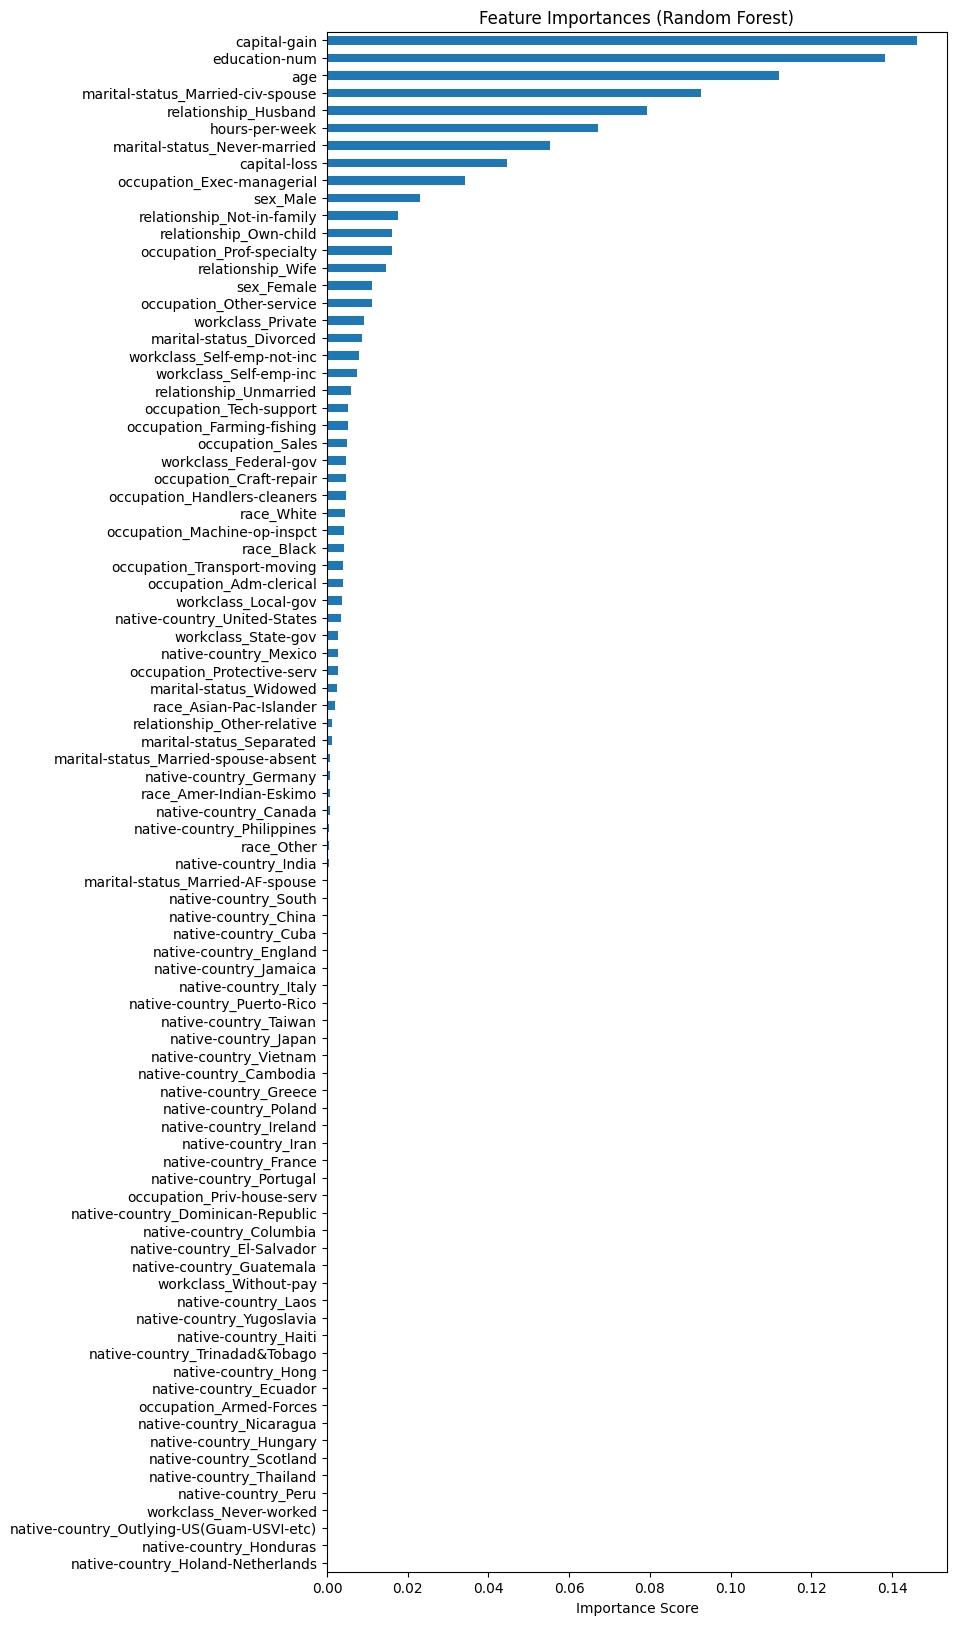

In [ ]:
importances = pd.Series(best_forest.feature_importances_, index=x_train.columns)
importances.sort_values().plot(kind = 'barh', figsize = (8,20))

plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

## Model Ranking – Best to Worst

| Rank | Model                   |   Accuracy | F1-score (`>50K`) | Finding                                                                                                                                                                                        |
| ---- | ----------------------- | ---------: | ----------------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1 | **XGBoost**             | **88.08%** |          **0.74** | XGBoost achieved the best overall performance, with the highest accuracy and F1-score for the `>50K` class. It provides the best balance between precision and recall among the tested models. |
| 2 | **Tuned Random Forest** | **87.09%** |          **0.70** | Hyperparameter tuning improved the test accuracy from 84.97% to 87.09% and increased the F1-score for `>50K` from 0.67 to 0.70.                                                                |
| 3 | **Tuned Decision Tree** | **86.45%** |          **0.68** | Pruning improved the tree's generalization and reduced overfitting, increasing the test accuracy from 82.61% to 86.45%.                                                                        |
| 4    | **Logistic Regression** | **85.57%** |          **0.67** | Logistic Regression achieved good overall performance and provided a simple baseline model, but its recall for `>50K` was only 0.62.                                                           |
| 5    | **SVM**                 | **85.51%** |          **0.67** | SVM achieved performance very similar to Logistic Regression, with 85.51% accuracy and an F1-score of 0.67 for the `>50K` class.                                                               |
| 6    | **KNN**                 | **84.75%** |          **0.66** | KNN achieved reasonable performance, and tuning the number of neighbors improved its results, but it remained below the tree-based models.                                                     |

### Overall Finding

> **XGBoost performed the best, achieving the highest accuracy (88.08%) and F1-score (0.74) for the `>50K` class. Tuned Random Forest and Decision Tree followed, while Logistic Regression, SVM, and KNN achieved slightly lower performance.**


**Log Transformation Experiment**

Since capital-gain and capital-loss were highly right-skewed, we tested a log1p transformation to reduce the effect of extreme values. However, the transformation did not lead to a meaningful improvement in model performance. XGBoost remained at 88.08% accuracy with an F1-score of 0.74 for the >50K class, while the tuned Random Forest remained at 87.09% accuracy with an F1-score of 0.70. Therefore, we decided not to use the log transformation in the final preprocessing pipeline.

Although the dataset is imbalanced, we evaluated SMOTE, class weighting, scale_pos_weight, and undersampling. These methods improved recall for the minority class but reduced precision, accuracy, or F1-score. Since our goal is to achieve a good overall balance between these metrics, the original XGBoost model was selected as the final model.